In [12]:
from collections import Counter

import networkx as nx
import numpy as np
from networkx.utils import weighted_choice
import networkx as nx
import matplotlib.pyplot as plt

GRAPH_TYPES = [f"random_{x}_out" for x in range(0, 6)] + ["scale_free", "cycle", "fully_connected"]


In [386]:
from os import chdir
from pathlib import Path

cwd = Path.cwd()
print(f"CWD: {cwd}")
if cwd.name == "code":
    chdir("..")
print(f"CWD: {Path.cwd()}")

CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main/code
CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main


In [6]:
def random_k_out_graph(n, k, alpha=50, self_loops=False, seed=None):
    rng = np.random.default_rng(seed)
    if alpha < 0:
        raise ValueError("alpha must be positive")
    G = nx.empty_graph(n, create_using=nx.MultiDiGraph)
    weights = Counter({v: alpha for v in G})
    for i in range(k * n):
        u = rng.choice([v for v, d in G.out_degree() if d < k])

        if not self_loops:
            adjustment = Counter({u: weights[u]})
        else:
            adjustment = Counter()
        v = weighted_choice(weights - adjustment, seed=rng)
        G.add_edge(u, v)
        weights[v] += 1
    return G


def create_random_5_out_graph(n_users, seed=1):
    return random_k_out_graph(n=n_users, k=5, alpha=50, seed=seed)


def create_random_2_out_graph(n_users, seed=1):
    return random_k_out_graph(n=n_users, k=2, alpha=50, seed=seed)


def create_scale_free_graph(n_users, seed=1):
    return nx.scale_free_graph(
        n_users,
        alpha=0.50,
        beta=0.25,
        gamma=0.25,
        delta_in=0.2,
        delta_out=0,
        seed=seed,
    )


def create_cycle_graph(n_users):
    return nx.cycle_graph(n_users).to_directed()


def add_order(graph: nx.Graph):
    new_graph = graph.copy()
    for i in graph:
        new_nbrs = set()
        first_nbrs = list(graph.neighbors(i))
        second_nbrs = []
        for nbr in first_nbrs:
            second_nbrs.extend(list(graph.neighbors(nbr)))
        for sec in second_nbrs:
            if i != sec:
                new_nbrs.add(sec)
        # print(f"Node {i} | 1st: {list(first_nbrs)} | 2nd: {second_nbrs} | all: {new_nbrs} | {len(new_nbrs)}")
        for new_nbr in new_nbrs:
            new_graph.add_edge(i, new_nbr)
    return new_graph


def create_graph(graph_type: str, n_users: int, seed: int = 1, order=1):
    if graph_type in [f"random_{k}_out" for k in range(0, 6)]:
        k = int(graph_type.split("_")[1])
        graph = random_k_out_graph(n=n_users, k=k, seed=seed)
    elif graph_type == "scale_free":
        graph = create_scale_free_graph(n_users, seed)
    elif graph_type == "cycle":
        graph = create_cycle_graph(n_users)
    elif graph_type == "fully_connected":
        graph = nx.complete_graph(n=n_users)
    else:
        raise NotImplementedError
    for _ in range(order - 1):
        graph = add_order(graph)
    return graph


In [74]:
graph_type = ["random_2_out", "random_5_out", "scale_free", "cycle", "fully_connected"]


In [96]:
G = create_graph(graph_type=graph_type[2], n_users=50, seed=1, order=3)

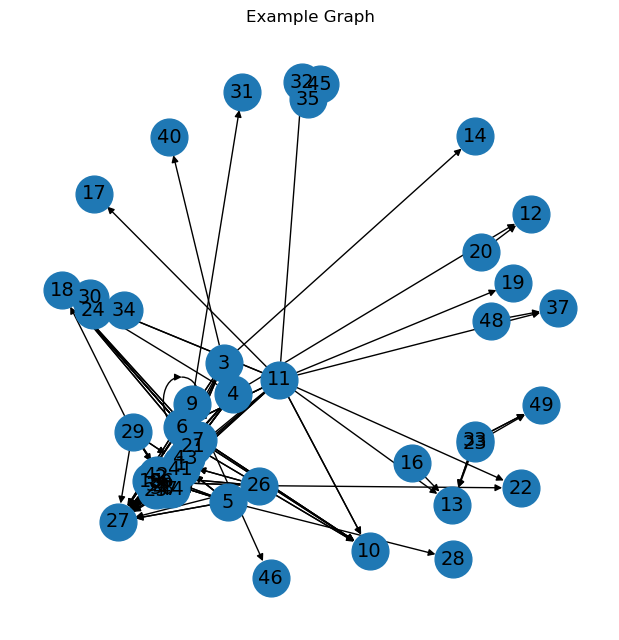

In [98]:
# Draw the graph
plt.figure(figsize=(6, 6))
nx.draw(G, with_labels=True, node_size=700, font_size=14)
plt.title("Example Graph")
plt.show()


In [372]:
count_list = {}
for i in np.arange(4):
    graph = create_graph(graph_type[i], n_users=10, seed=1)
    g = graph.copy()
    order = 5
    temp_list =[]
    for j in np.arange(1,order+1):
        for n in range(j-1):
            g = add_order(g)
        total = 0
        for node in g:
            nbrs = list(g.neighbors(node))
            #print(f"Node: {i} | Nbrs: {nbrs} | N: {len(nbrs)} | NOT: {set(range(20)) - set(nbrs)}")
            total = total + len(nbrs)
        temp_list = np.append(temp_list, total)
    count_list[graph_type[i]] = temp_list

In [374]:
count_list_directed = count_list

In [376]:
count_list = {}
for i in np.arange(4):
    graph = create_graph(graph_type[i], n_users=10, seed=1).to_undirected()
    g = graph.copy()
    order = 5
    temp_list =[]
    for j in np.arange(1,order+1):
        for n in range(j-1):
            g = add_order(g)
        total = 0
        for node in g:
            nbrs = list(g.neighbors(node))
            #print(f"Node: {i} | Nbrs: {nbrs} | N: {len(nbrs)} | NOT: {set(range(20)) - set(nbrs)}")
            total = total + len(nbrs)
        temp_list = np.append(temp_list, total)
    count_list[graph_type[i]] = temp_list

In [378]:
count_list_undirected = count_list

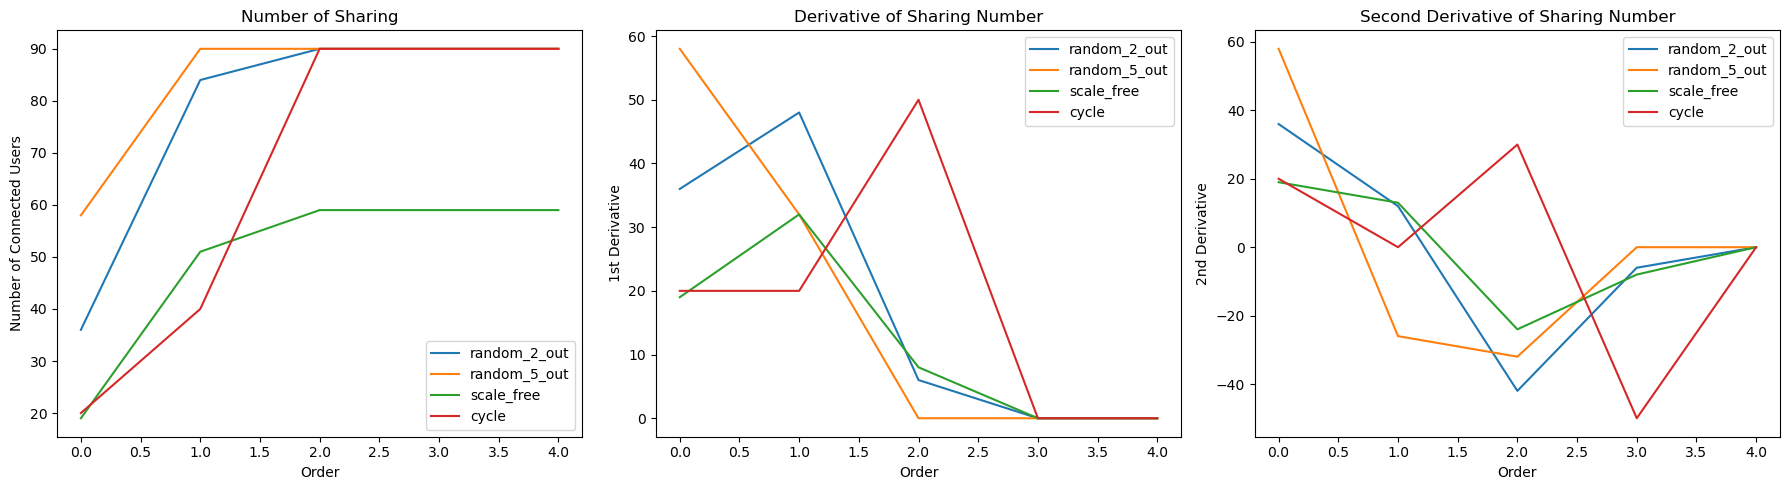

In [356]:
data = count_list_undirected
orders = np.arange(len(next(iter(data.values()))))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# First plot
for key, values in data.items():
    style = '-' if key != 'fully_connected' else '--'
    axs[0].plot(orders, values, style, label=key)
axs[0].set_xlabel('Order')
axs[0].set_ylabel('Number of Connected Users')
axs[0].set_title('Number of Sharing')
axs[0].legend()

# Second plot (first derivative)
for key, values in data.items():
    derivative1 = np.diff(values, prepend=0)
    style = '-' if key != 'fully_connected' else '--'
    axs[1].plot(orders, derivative1, style, label=key)
axs[1].set_xlabel('Order')
axs[1].set_ylabel('1st Derivative')
axs[1].set_title('Derivative of Sharing Number')
axs[1].legend()

# Third plot (second derivative)
for key, values in data.items():
    derivative1 = np.diff(values, prepend=0)
    derivative2 = np.diff(derivative1, prepend=0)
    style = '-' if key != 'fully_connected' else '--'
    axs[2].plot(orders, derivative2, style, label=key)
axs[2].set_xlabel('Order')
axs[2].set_ylabel('2nd Derivative')
axs[2].set_title('Second Derivative of Sharing Number')
axs[2].legend()

plt.tight_layout()
plt.show()

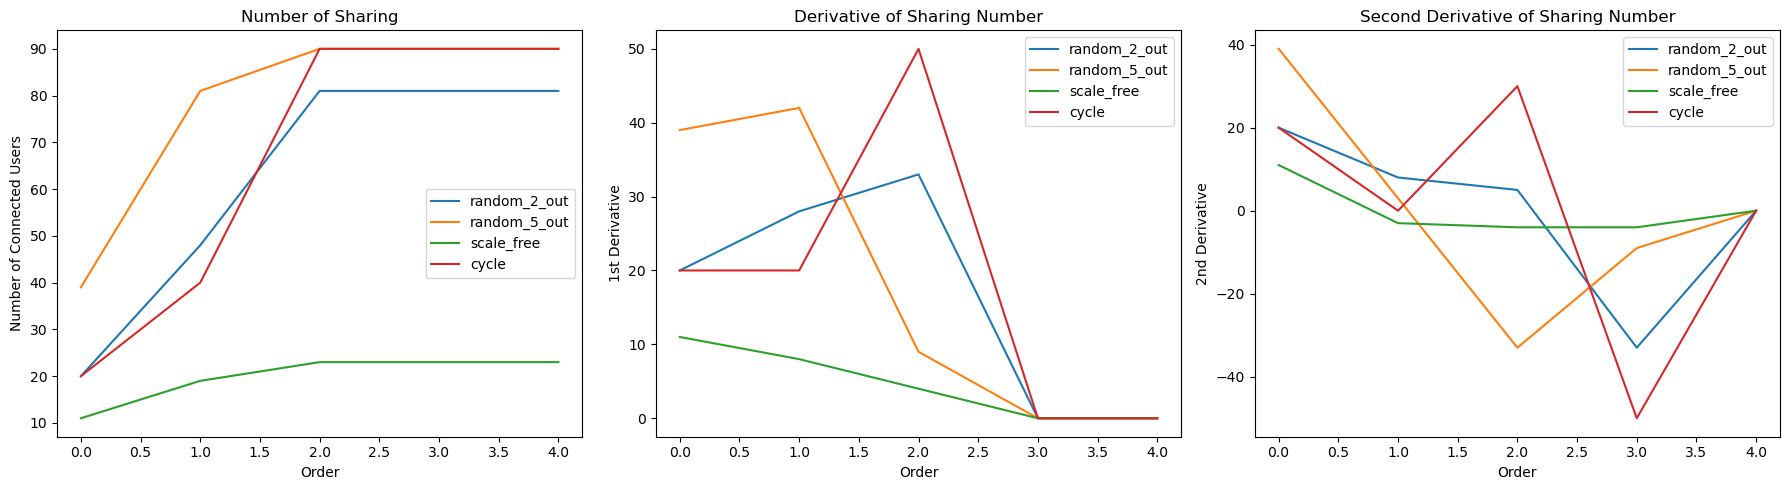

In [380]:
data = count_list_directed
orders = np.arange(len(next(iter(data.values()))))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# First plot
for key, values in data.items():
    style = '-' if key != 'fully_connected' else '--'
    axs[0].plot(orders, values, style, label=key)
axs[0].set_xlabel('Order')
axs[0].set_ylabel('Number of Connected Users')
axs[0].set_title('Number of Sharing')
axs[0].legend()

# Second plot (first derivative)
for key, values in data.items():
    derivative1 = np.diff(values, prepend=0)
    style = '-' if key != 'fully_connected' else '--'
    axs[1].plot(orders, derivative1, style, label=key)
axs[1].set_xlabel('Order')
axs[1].set_ylabel('1st Derivative')
axs[1].set_title('Derivative of Sharing Number')
axs[1].legend()

# Third plot (second derivative)
for key, values in data.items():
    derivative1 = np.diff(values, prepend=0)
    derivative2 = np.diff(derivative1, prepend=0)
    style = '-' if key != 'fully_connected' else '--'
    axs[2].plot(orders, derivative2, style, label=key)
axs[2].set_xlabel('Order')
axs[2].set_ylabel('2nd Derivative')
axs[2].set_title('Second Derivative of Sharing Number')
axs[2].legend()

plt.tight_layout()
plt.show()



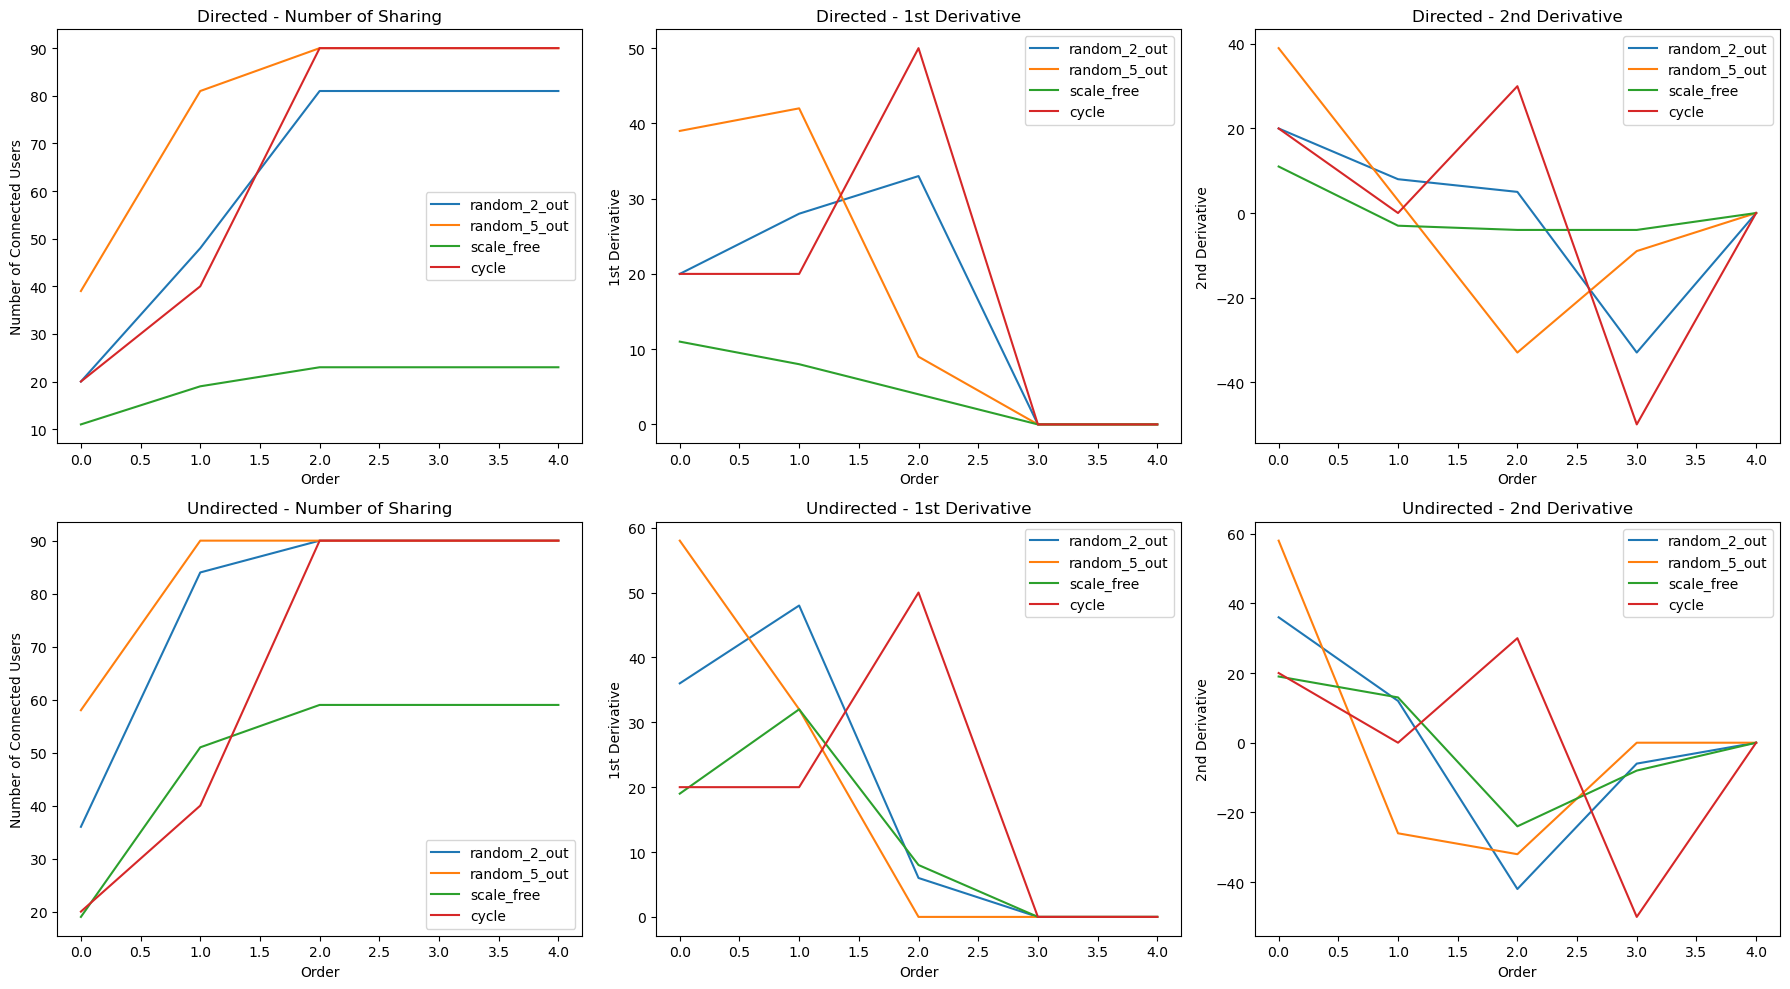

In [388]:
data_directed = count_list_directed
data_undirected = count_list_undirected
orders = np.arange(len(next(iter(data_directed.values()))))

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Directed plots
for key, values in data_directed.items():
    style = '-' if key != 'fully_connected' else '--'
    axs[0, 0].plot(orders, values, style, label=key)
    derivative1 = np.diff(values, prepend=0)
    axs[0, 1].plot(orders, derivative1, style, label=key)
    derivative2 = np.diff(derivative1, prepend=0)
    axs[0, 2].plot(orders, derivative2, style, label=key)

axs[0, 0].set_title('Directed - Number of Sharing')
axs[0, 1].set_title('Directed - 1st Derivative')
axs[0, 2].set_title('Directed - 2nd Derivative')

# Undirected plots
for key, values in data_undirected.items():
    style = '-' if key != 'fully_connected' else '--'
    axs[1, 0].plot(orders, values, style, label=key)
    derivative1 = np.diff(values, prepend=0)
    axs[1, 1].plot(orders, derivative1, style, label=key)
    derivative2 = np.diff(derivative1, prepend=0)
    axs[1, 2].plot(orders, derivative2, style, label=key)

axs[1, 0].set_title('Undirected - Number of Sharing')
axs[1, 1].set_title('Undirected - 1st Derivative')
axs[1, 2].set_title('Undirected - 2nd Derivative')

# Labels and legends
for ax_row in axs:
    for ax in ax_row:
        ax.set_xlabel('Order')
        ax.legend()

axs[0, 0].set_ylabel('Number of Connected Users')
axs[1, 0].set_ylabel('Number of Connected Users')
axs[0, 1].set_ylabel('1st Derivative')
axs[1, 1].set_ylabel('1st Derivative')
axs[0, 2].set_ylabel('2nd Derivative')
axs[1, 2].set_ylabel('2nd Derivative')

plt.tight_layout()
plt.savefig('ResultData/neighbor_sharing_analysis.png')
plt.show()


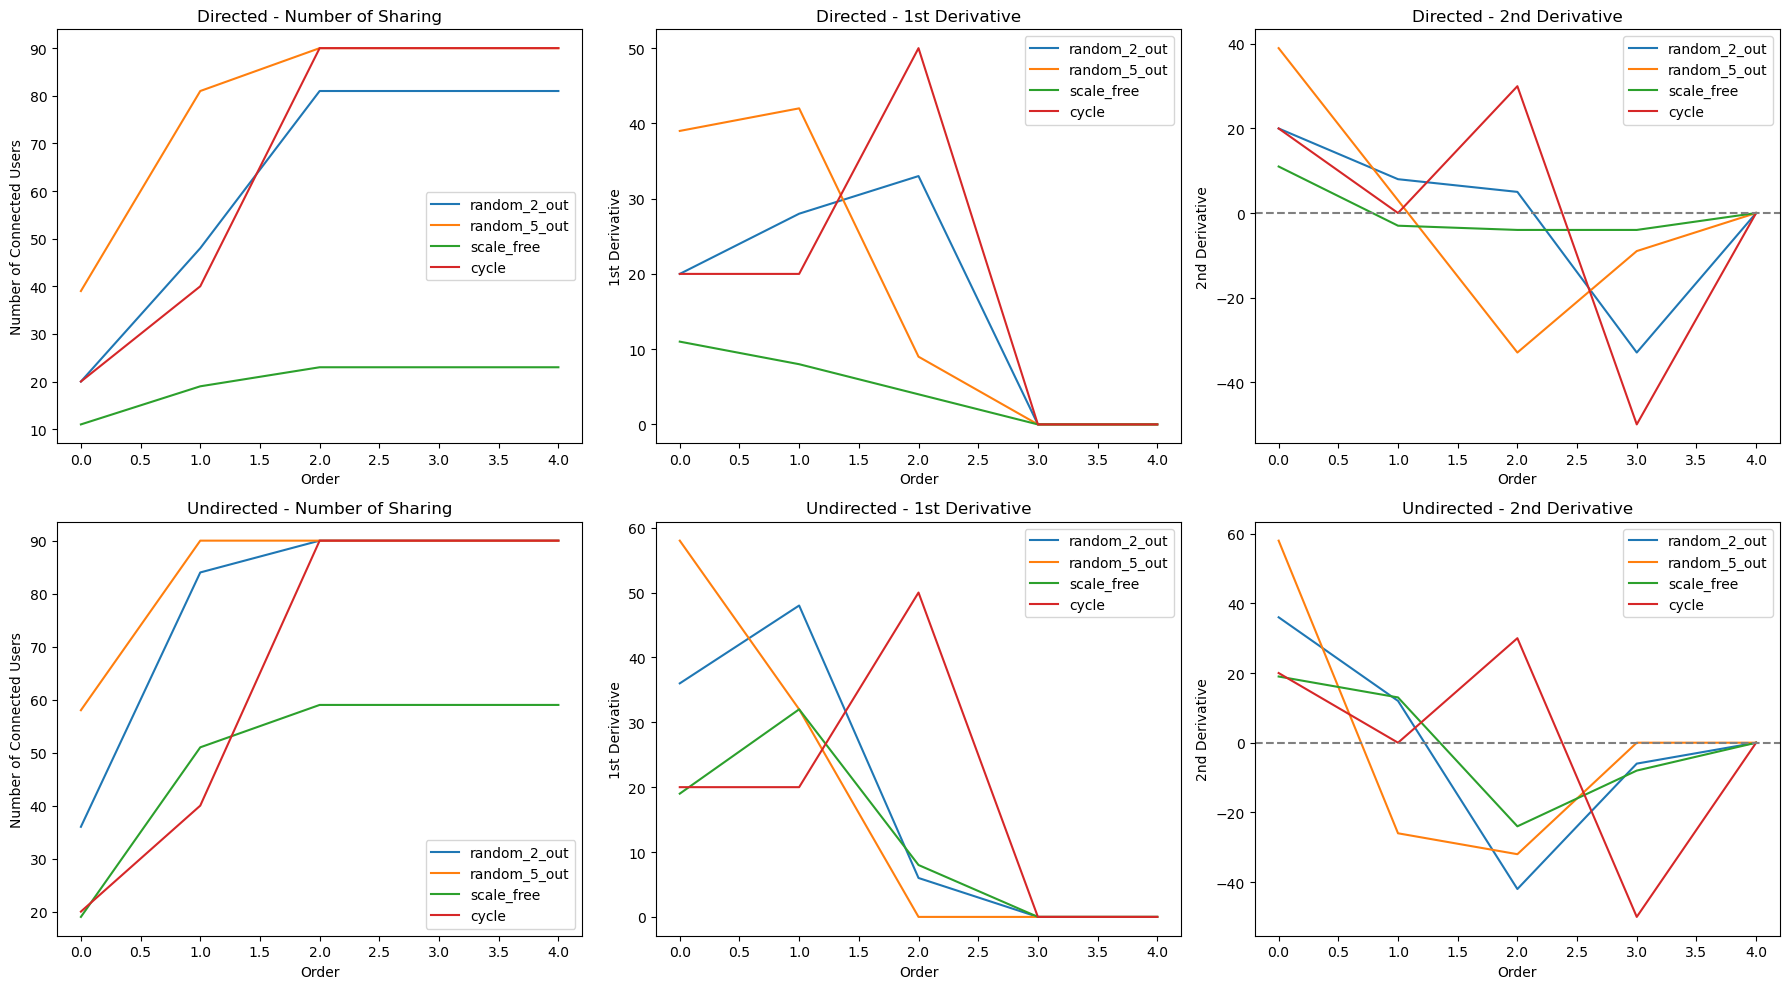

In [392]:
data_directed = count_list_directed
data_undirected = count_list_undirected
orders = np.arange(len(next(iter(data_directed.values()))))

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Directed plots
for key, values in data_directed.items():
    style = '-' if key != 'fully_connected' else '--'
    axs[0, 0].plot(orders, values, style, label=key)
    derivative1 = np.diff(values, prepend=0)
    axs[0, 1].plot(orders, derivative1, style, label=key)
    derivative2 = np.diff(derivative1, prepend=0)
    axs[0, 2].plot(orders, derivative2, style, label=key)
axs[0, 2].axhline(0, color='gray', linestyle='--')

axs[0, 0].set_title('Directed - Number of Sharing')
axs[0, 1].set_title('Directed - 1st Derivative')
axs[0, 2].set_title('Directed - 2nd Derivative')

# Undirected plots
for key, values in data_undirected.items():
    style = '-' if key != 'fully_connected' else '--'
    axs[1, 0].plot(orders, values, style, label=key)
    derivative1 = np.diff(values, prepend=0)
    axs[1, 1].plot(orders, derivative1, style, label=key)
    derivative2 = np.diff(derivative1, prepend=0)
    axs[1, 2].plot(orders, derivative2, style, label=key)
axs[1, 2].axhline(0, color='gray', linestyle='--')

axs[1, 0].set_title('Undirected - Number of Sharing')
axs[1, 1].set_title('Undirected - 1st Derivative')
axs[1, 2].set_title('Undirected - 2nd Derivative')

# Labels and legends
for ax_row in axs:
    for ax in ax_row:
        ax.set_xlabel('Order')
        ax.legend()

axs[0, 0].set_ylabel('Number of Connected Users')
axs[1, 0].set_ylabel('Number of Connected Users')
axs[0, 1].set_ylabel('1st Derivative')
axs[1, 1].set_ylabel('1st Derivative')
axs[0, 2].set_ylabel('2nd Derivative')
axs[1, 2].set_ylabel('2nd Derivative')

plt.tight_layout()
plt.savefig('ResultData/neighbor_sharing_analysis.png')
plt.show()


In [324]:
count_list_undirected

{'random_2_out': array([36., 84., 90., 90., 90.]),
 'random_5_out': array([58., 90., 90., 90., 90.]),
 'scale_free': array([19., 51., 59., 59., 59.]),
 'cycle': array([20., 40., 90., 90., 90.])}

In [326]:
count_list_directed

{'random_2_out': array([20., 48., 81., 81., 81.]),
 'random_5_out': array([39., 81., 90., 90., 90.]),
 'scale_free': array([11., 19., 23., 23., 23.]),
 'cycle': array([20., 40., 90., 90., 90.])}

In [334]:
import pandas as pd
df = pd.DataFrame.from_dict(count_list_directed, orient='index', columns=[1, 2, 3, 4, 5])

# Output LaTeX table
latex_table = df.to_latex()
print(latex_table)


\begin{tabular}{lrrrrr}
\toprule
 & 1 & 2 & 3 & 4 & 5 \\
\midrule
random_2_out & 20.000000 & 48.000000 & 81.000000 & 81.000000 & 81.000000 \\
random_5_out & 39.000000 & 81.000000 & 90.000000 & 90.000000 & 90.000000 \\
scale_free & 11.000000 & 19.000000 & 23.000000 & 23.000000 & 23.000000 \\
cycle & 20.000000 & 40.000000 & 90.000000 & 90.000000 & 90.000000 \\
\bottomrule
\end{tabular}



In [336]:
df = pd.DataFrame.from_dict(count_list_undirected, orient='index', columns=[1, 2, 3, 4, 5])

# Output LaTeX table
latex_table = df.to_latex()
print(latex_table)


\begin{tabular}{lrrrrr}
\toprule
 & 1 & 2 & 3 & 4 & 5 \\
\midrule
random_2_out & 36.000000 & 84.000000 & 90.000000 & 90.000000 & 90.000000 \\
random_5_out & 58.000000 & 90.000000 & 90.000000 & 90.000000 & 90.000000 \\
scale_free & 19.000000 & 51.000000 & 59.000000 & 59.000000 & 59.000000 \\
cycle & 20.000000 & 40.000000 & 90.000000 & 90.000000 & 90.000000 \\
\bottomrule
\end{tabular}



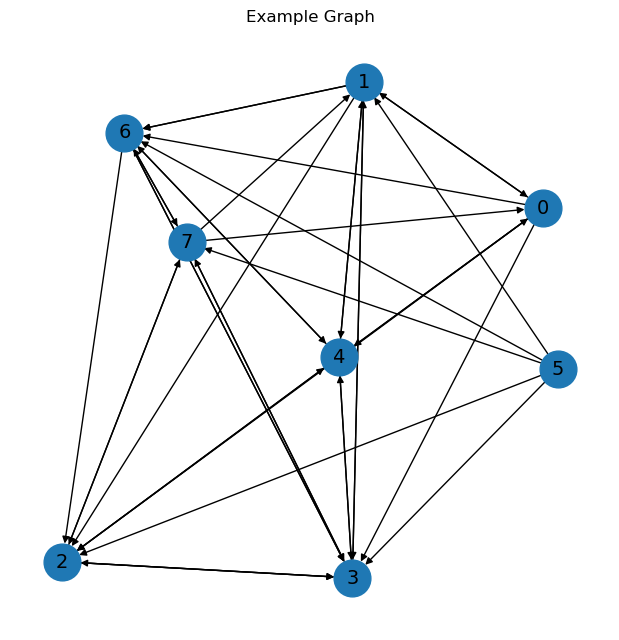

In [283]:
# Draw the graph
G = create_graph("random_2_out", n_users=8, seed=1,order = 2)
plt.figure(figsize=(6, 6))
nx.draw(G, with_labels=True, node_size=700, font_size=14)
plt.title("Example Graph")
plt.show()

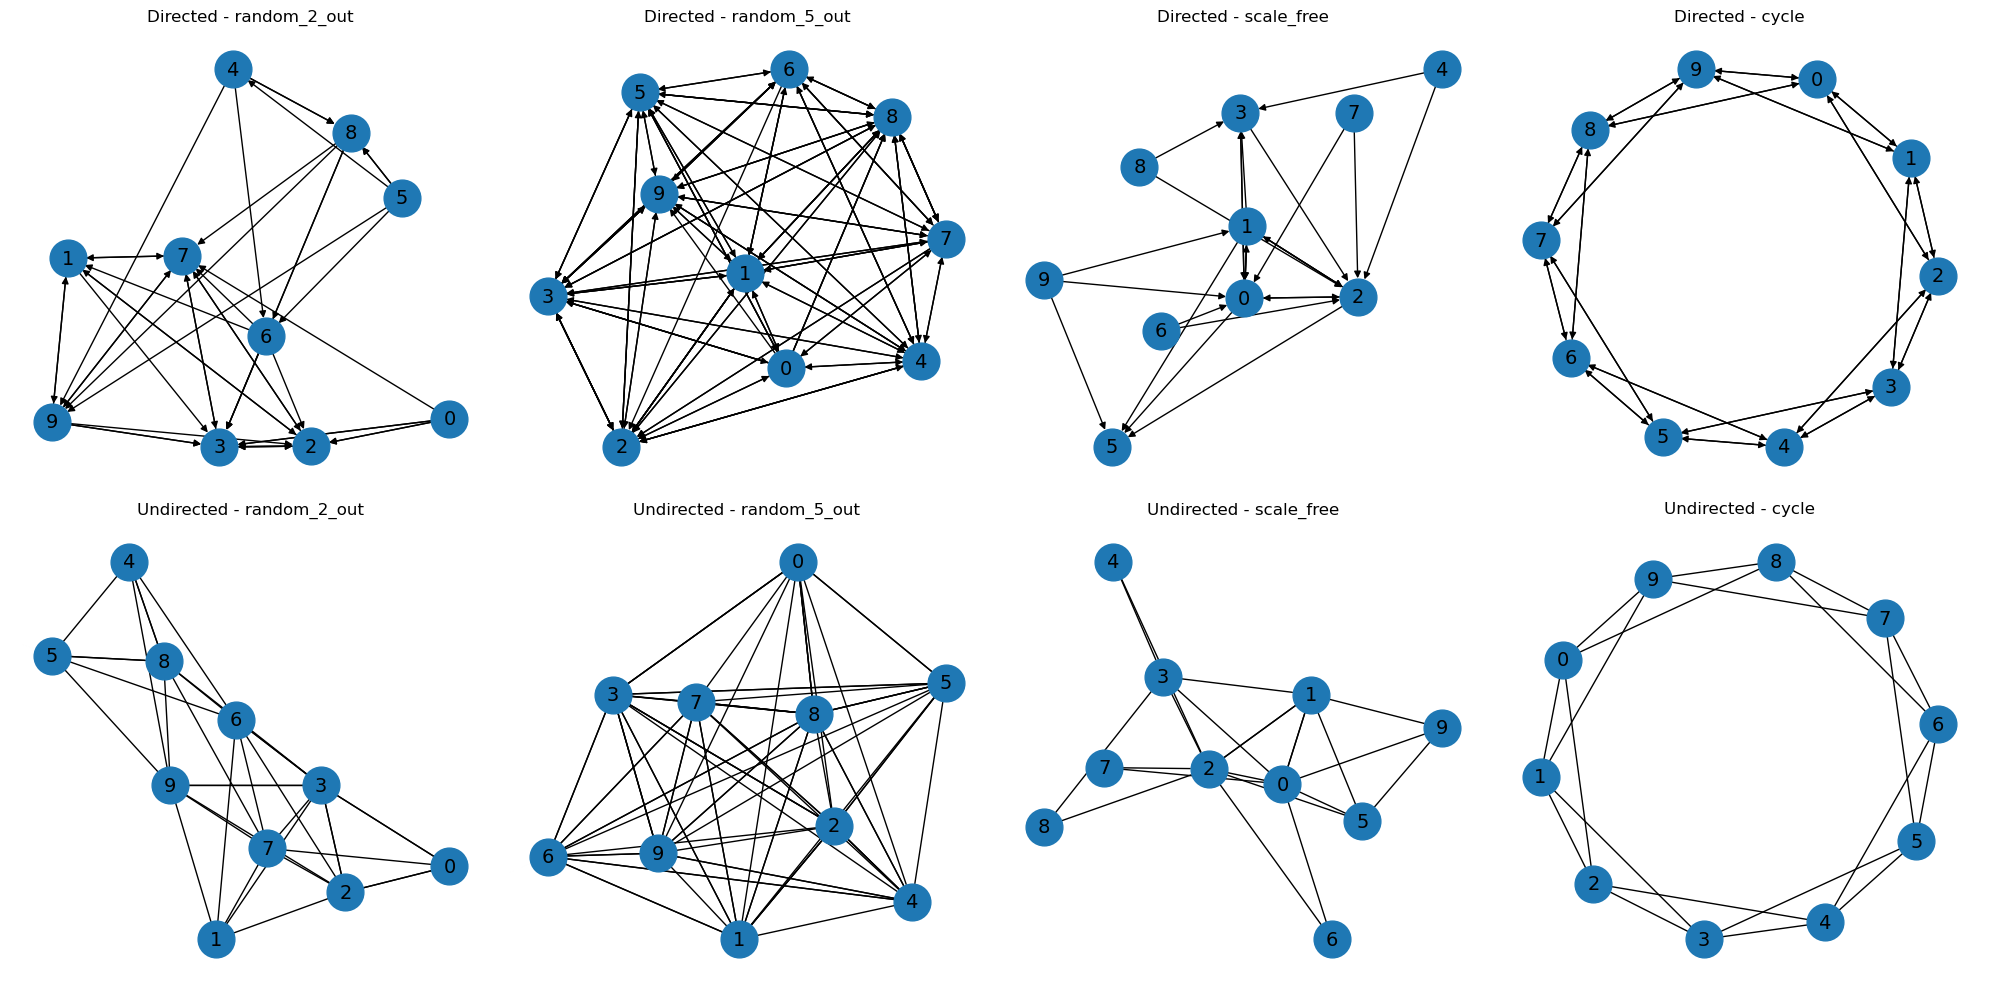

In [404]:
graph_types = ["random_2_out", "random_5_out", "scale_free", "cycle"]
n_users = 10
seed = 10

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

for col, graph_type in enumerate(graph_types):
    # Directed
    G_directed = create_graph(graph_type, n_users=n_users, seed=seed, order=2)
    nx.draw(G_directed, ax=axs[0, col], with_labels=True, node_size=700, font_size=14)
    axs[0, col].set_title(f"Directed - {graph_type}")

    # Undirected
    G_undirected = G_directed.to_undirected()
    nx.draw(G_undirected, ax=axs[1, col], with_labels=True, node_size=700, font_size=14)
    axs[1, col].set_title(f"Undirected - {graph_type}")

plt.tight_layout()
plt.savefig('ResultData/network_illustration.png')
plt.show()


In [338]:
data = {
    'random_2_out_directed': [20, 48, 81, 81, 81],
    'random_5_out_directed': [39, 81, 90, 90, 90],
    'scale_free_directed': [11, 19, 23, 23, 23],
    'cycle_directed': [20, 40, 90, 90, 90],
    'random_2_out_undirected': [36, 84, 90, 90, 90],
    'random_5_out_undirected': [58, 90, 90, 90, 90],
    'scale_free_undirected': [19, 51, 59, 59, 59],
    'cycle_undirected': [20, 40, 90, 90, 90]
}

df = pd.DataFrame.from_dict(data, orient='index', columns=[1,2,3,4,5])

# Compute first and second derivatives
derivative1 = df.diff(axis=1, periods=1).fillna(0)
derivative2 = derivative1.diff(axis=1, periods=1).fillna(0)

print("First Derivative:\n", derivative1)
print("\nSecond Derivative:\n", derivative2)


First Derivative:
                            1   2   3  4  5
random_2_out_directed    0.0  28  33  0  0
random_5_out_directed    0.0  42   9  0  0
scale_free_directed      0.0   8   4  0  0
cycle_directed           0.0  20  50  0  0
random_2_out_undirected  0.0  48   6  0  0
random_5_out_undirected  0.0  32   0  0  0
scale_free_undirected    0.0  32   8  0  0
cycle_undirected         0.0  20  50  0  0

Second Derivative:
                            1     2   3   4  5
random_2_out_directed    0.0  28.0   5 -33  0
random_5_out_directed    0.0  42.0 -33  -9  0
scale_free_directed      0.0   8.0  -4  -4  0
cycle_directed           0.0  20.0  30 -50  0
random_2_out_undirected  0.0  48.0 -42  -6  0
random_5_out_undirected  0.0  32.0 -32   0  0
scale_free_undirected    0.0  32.0 -24  -8  0
cycle_undirected         0.0  20.0  30 -50  0


In [342]:
latex_table = derivative2.to_latex()
print(latex_table)

\begin{tabular}{lrrrrr}
\toprule
 & 1 & 2 & 3 & 4 & 5 \\
\midrule
random_2_out_directed & 0.000000 & 28.000000 & 5 & -33 & 0 \\
random_5_out_directed & 0.000000 & 42.000000 & -33 & -9 & 0 \\
scale_free_directed & 0.000000 & 8.000000 & -4 & -4 & 0 \\
cycle_directed & 0.000000 & 20.000000 & 30 & -50 & 0 \\
random_2_out_undirected & 0.000000 & 48.000000 & -42 & -6 & 0 \\
random_5_out_undirected & 0.000000 & 32.000000 & -32 & 0 & 0 \\
scale_free_undirected & 0.000000 & 32.000000 & -24 & -8 & 0 \\
cycle_undirected & 0.000000 & 20.000000 & 30 & -50 & 0 \\
\bottomrule
\end{tabular}

